In [14]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [15]:
df=pd.read_csv('Food_Delivery_Time_Prediction.csv')

In [16]:
df.shape

(50000, 24)

In [17]:
df.head()


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [18]:
df=df.drop(columns=['Order_ID', 'Order_Date'])

In [19]:
df['Order_Hour']=df['Order_Hour'].astype('int8')
df['Is_Weekend']=df['Is_Weekend'].astype('int8')
df['Is_Festival']=df['Is_Festival'].astype('int8')
df['Rider_Experience_Years']=df['Rider_Experience_Years'].astype('float16')
df['Rider_Rating']=df['Rider_Rating'].astype('float16')
df['Restaurant_Rating']=df['Restaurant_Rating'].astype('float16')
df['Order_Items']=df['Order_Items'].astype('int8')
df['Preparation_Time_Min']=df['Preparation_Time_Min'].astype('int8')
df['Road_Distance_km']=df['Road_Distance_km'].astype('float16')
df['Number_of_Signals']=df['Number_of_Signals'].astype('int8')
df['Average_Speed_kmph']=df['Average_Speed_kmph'].astype('float16')
df['Time_taken_min']=df['Time_taken_min'].astype('int8')


In [20]:
df.select_dtypes(exclude='object').columns

Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')

In [21]:
def get_features():
    nom_cols=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
    ord_cols=['Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']
    num_cols=['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating',
            'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km',
            'Number_of_Signals', 'Average_Speed_kmph']
    return num_cols, ord_cols, nom_cols

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

def get_preprocessor(numerical_data, ordinal_data, nominal_data):
    num_pipeline = Pipeline(
        steps=[
            ('impute', SimpleImputer(strategy='mean')),
            ('scaling', StandardScaler())
        ]
    )

    ord_pipeline = Pipeline(
        steps=[
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encoding', OrdinalEncoder(
                categories=[
                    ['Low', 'Medium', 'High'],
                    ['Short', 'Medium', 'Long'],
                    ['Low', 'Moderate', 'High', 'Severe'],
                    ['Normal', 'Priority', 'VIP']                
                ],
                handle_unknown='use_encoded_value', 
                unknown_value=-1
            )),
            ('scaling', StandardScaler())
        ]
    )

    nom_pipeline = Pipeline(
        steps=[
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]
    )

    features = ColumnTransformer(
        transformers=[
            ('Numerical Pipeline', num_pipeline, numerical_data),
            ('Ordinal Pipeline', ord_pipeline, ordinal_data),
            ('Nominal Pipeline', nom_pipeline, nominal_data)
        ]
    )

    return features

In [23]:
X=df.iloc[:,:-1]
y=df['Time_taken_min']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [25]:
num_data, ord_data, nom_data = get_features()
features = get_preprocessor(num_data, ord_data, nom_data)

In [26]:
X_train=features.fit_transform(X_train)
X_test=features.transform(X_test)

In [27]:
models_to_run=['lr','forest', 'ada', 'neighbors', 'xgb', 'cat']

model_instances={
    'lr':LinearRegression(),
    'forest':RandomForestRegressor(random_state=42),
    'ada':AdaBoostRegressor(random_state=42),
    'neighbors':KNeighborsRegressor(),
    'xgb':XGBRegressor(random_state=42),
    'cat':CatBoostRegressor(random_state=42, verbose=0)
}

para_grid={
    'lr': {'fit_intercept':[True, False]},
    'forest': {'n_estimators':[50, 100, 150, 200], 'max_depth':[None, 5, 10, 15]},
    'ada': {'n_estimators':[50, 100, 150, 200], 'learning_rate':[0.01, 0.1, 1]},
    'neighbors': {'n_neighbors':[3, 5, 10, 15], 'weights':['uniform', 'distance']},
    'xgb': {'n_estimators':[50, 100, 150, 200], 'learning_rate':[0.01, 0.1], 'max_depth':[3, 5, 7]},
    'cat': {'iterations':[25, 50, 100, 150], 'learning_rate':[0.01, 0.1], 'depth':[4, 6, 8]}
}

best_models={}

In [28]:
for name in models_to_run:
    print(f'Tuning {name}')

    grid_search=RandomizedSearchCV(
        estimator=model_instances[name],
        param_distributions=para_grid[name],
        n_iter=10,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    grid_search.fit(X_train, y_train)

    tuned_model=grid_search.best_estimator_

    y_pred = tuned_model.predict(X_test)

    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    best_models[name] = {
        'best_estimator': tuned_model,
        'best_params': grid_search.best_params_,
        'best_cv_mse': -grid_search.best_score_,
        'test_mse': test_mse,
        'test_r2': test_r2
    }
    
    print(f"Best parameters: {best_models[name]['best_params']}")
    print(f"Best CV MSE: {best_models[name]['best_cv_mse']:.4f}")
    print(f"Test MSE: {best_models[name]['test_mse']:.4f}")
    print(f"Test R2 Score: {best_models[name]['test_r2']:.4f}\n")
    print("-" * 50)

Tuning lr


d:\ML_Projects\Delivery_Time_Prediction\venv_project\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'fit_intercept': True}
Best CV MSE: 2882.5862
Test MSE: 2917.8677
Test R2 Score: 0.2150

--------------------------------------------------
Tuning forest
Best parameters: {'n_estimators': 150, 'max_depth': None}
Best CV MSE: 619.2093
Test MSE: 544.9136
Test R2 Score: 0.8534

--------------------------------------------------
Tuning ada
Best parameters: {'n_estimators': 150, 'learning_rate': 0.01}
Best CV MSE: 1597.6770
Test MSE: 1610.5527
Test R2 Score: 0.5667

--------------------------------------------------
Tuning neighbors


d:\ML_Projects\Delivery_Time_Prediction\venv_project\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'weights': 'distance', 'n_neighbors': 15}
Best CV MSE: 2163.6504
Test MSE: 2127.0888
Test R2 Score: 0.4278

--------------------------------------------------
Tuning xgb
Best parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}
Best CV MSE: 678.2570
Test MSE: 622.0783
Test R2 Score: 0.8327

--------------------------------------------------
Tuning cat
Best parameters: {'learning_rate': 0.1, 'iterations': 100, 'depth': 8}
Best CV MSE: 791.4728
Test MSE: 757.2467
Test R2 Score: 0.7963

--------------------------------------------------


In [29]:
joblib.dump(features, 'preprocessor.pkl')
rf_model = best_models['forest']['best_estimator']
joblib.dump(rf_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

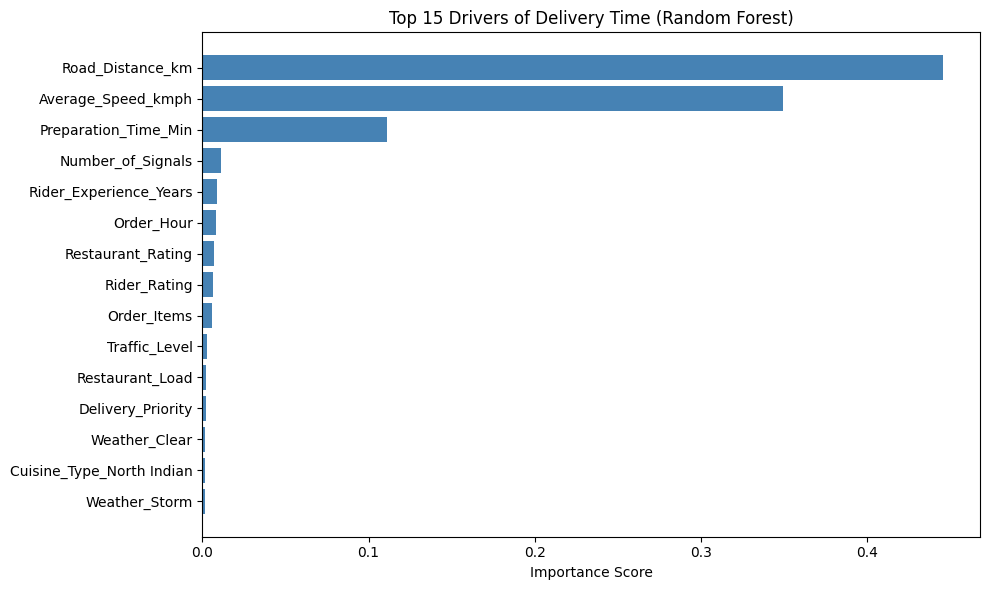

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Retrieve the exact feature names created by the ColumnTransformer
# Get the One-Hot Encoded names from the Nominal Pipeline
nom_encoder = features.named_transformers_['Nominal Pipeline'].named_steps['encoding']
nom_feature_names = nom_encoder.get_feature_names_out(nom_data)

# Combine numerical, ordinal, and nominal feature names in order using your global variables
all_feature_names = np.concatenate([num_data, ord_data, nom_feature_names])

# 2. Extract importance scores from the tuned Random Forest
importances = rf_model.feature_importances_

# 3. Create a DataFrame and sort the top 15 most impactful features
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
top_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='steelblue')
plt.title('Top 15 Drivers of Delivery Time (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()